In [1]:
# 模块1：导入依赖并固定随机种子
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


In [2]:
# 模块2：配置参数与路径
class Config:
    root_dir = Path('.')
    data_dir = root_dir / 'Data'
    artifact_dir = root_dir / 'saved_dict'
    figure_dir = root_dir / 'figures'
    train_path = data_dir / 'train.txt'
    dev_path = data_dir / 'dev.txt'
    test_path = data_dir / 'test.txt'
    class_path = data_dir / 'class.txt'
    save_path = artifact_dir / 'my_BiLSTM.pt'
    loss_curve_path = figure_dir / 'BiLSTM_loss_curve.png'

    # 是否按词切分；False 表示按字符切分
    use_word = False
    # 词表大小上限、最小词频和句子最大截断长度
    max_vocab_size = 10000
    min_freq = 1
    max_length = 32

    # 模型超参数：适度增大表示能力，同时提高 dropout 抑制过拟合
    embedding_dim = 200
    hidden_size = 192
    num_layers = 2
    dropout = 0.5

    # 训练超参数：加入权重衰减、标签平滑、学习率调度和早停
    batch_size = 64
    num_epochs = 20
    learning_rate = 8e-4
    weight_decay = 1e-4
    grad_clip = 1.0
    label_smoothing = 0.05
    early_stop_patience = 4
    scheduler_factor = 0.5
    scheduler_patience = 1

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


config = Config()
config.save_path.parent.mkdir(parents=True, exist_ok=True)
config.figure_dir.mkdir(parents=True, exist_ok=True)

with open(config.class_path, 'r', encoding='utf-8') as f:
    class_names = [line.strip() for line in f if line.strip()]

print(f'Classes: {class_names}')
print(f'Device: {config.device}')


Classes: ['finance', 'realty', 'education', 'science']
Device: cpu


In [3]:
# 模块3：读取数据并构建词表
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'


def tokenize(text):
    text = text.strip()
    return text.split() if config.use_word else list(text)


def read_samples(path):
    samples = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if not line:
                continue
            text, label = line.rsplit('\t', 1)
            tokens = tokenize(text)[: config.max_length]
            if not tokens:
                tokens = [UNK_TOKEN]
            samples.append((tokens, int(label), text))
    return samples


# 分别读取训练集、验证集和测试集
train_samples = read_samples(config.train_path)
dev_samples = read_samples(config.dev_path)
test_samples = read_samples(config.test_path)

counter = Counter()
for tokens, _, _ in train_samples:
    counter.update(tokens)

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for token, freq in counter.most_common(config.max_vocab_size - len(vocab)):
    if freq < config.min_freq:
        continue
    vocab[token] = len(vocab)

print(f'Train size: {len(train_samples)}')
print(f'Dev size: {len(dev_samples)}')
print(f'Test size: {len(test_samples)}')
print(f'Vocab size: {len(vocab)}')
print(f'Sample text: {train_samples[0][2]}')
print(f'Sample label id: {train_samples[0][1]} -> {class_names[train_samples[0][1]]}')


Train size: 2000
Dev size: 400
Test size: 400
Vocab size: 2131
Sample text: 国际能源机构上调全球原油需求预期
Sample label id: 0 -> finance


In [4]:
# 模块4：定义数据集与 DataLoader
class NewsDataset(Dataset):
    def __init__(self, samples, vocab):
        self.samples = samples
        self.vocab = vocab

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tokens, label, raw_text = self.samples[idx]
        ids = [self.vocab.get(token, self.vocab[UNK_TOKEN]) for token in tokens]
        return {
            'input_ids': ids,
            'label': label,
            'raw_text': raw_text,
        }


def collate_fn(batch):
    sequences = [torch.tensor(item['input_ids'], dtype=torch.long) for item in batch]
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    raw_texts = [item['raw_text'] for item in batch]

    # pack_padded_sequence 要求按长度从大到小排序
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    lengths, sort_idx = lengths.sort(descending=True)

    sequences = [sequences[i] for i in sort_idx.tolist()]
    labels = labels[sort_idx]
    raw_texts = [raw_texts[i] for i in sort_idx.tolist()]

    padded = pad_sequence(sequences, batch_first=True, padding_value=vocab[PAD_TOKEN])
    return padded, lengths, labels, raw_texts


train_dataset = NewsDataset(train_samples, vocab)
dev_dataset = NewsDataset(dev_samples, vocab)
test_dataset = NewsDataset(test_samples, vocab)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate_fn)

batch_inputs, batch_lengths, batch_labels, _ = next(iter(train_loader))
print(batch_inputs.shape, batch_lengths.shape, batch_labels.shape)


torch.Size([64, 32]) torch.Size([64]) torch.Size([64])


In [5]:
# 模块5：定义 BiLSTM 模型
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, config.embedding_dim, padding_idx=pad_idx)
        # 双向 LSTM 同时建模前向和后向上下文信息
        self.encoder = nn.LSTM(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=config.dropout if config.num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(config.dropout)
        self.fc = nn.Linear(config.hidden_size * 2, num_classes)

    # 前向传播：词嵌入 -> 打包序列 -> BiLSTM -> 拼接双向隐藏状态 -> 分类
    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hidden, _) = self.encoder(packed)
        # 取最后一层前向和后向隐状态拼接为句子表示
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        logits = self.fc(self.dropout(hidden))
        return logits


model = BiLSTMClassifier(
    vocab_size=len(vocab),
    num_classes=len(class_names),
    pad_idx=vocab[PAD_TOKEN],
).to(config.device)

print(model)


BiLSTMClassifier(
  (embedding): Embedding(2131, 200, padding_idx=0)
  (encoder): LSTM(200, 192, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=4, bias=True)
)


In [6]:
# 模块6：训练与评估函数
# 多分类任务使用带标签平滑的交叉熵损失，优化器改为 AdamW，并保留权重衰减
criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=config.scheduler_factor,
    patience=config.scheduler_patience,
)


# 单轮训练或验证；当 optimizer 为 None 时只进行前向评估
def run_epoch(model, data_loader, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    loss_list = []
    pred_list = []
    label_list = []

    progress = tqdm(data_loader, leave=False)
    for input_ids, lengths, labels, _ in progress:
        input_ids = input_ids.to(config.device)
        lengths = lengths.to(config.device)
        labels = labels.to(config.device)

        with torch.set_grad_enabled(is_train):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if is_train:
                # 训练阶段执行反向传播，并通过梯度裁剪稳定训练过程
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
                optimizer.step()

        preds = torch.argmax(logits, dim=1)
        loss_list.append(loss.item())
        pred_list.extend(preds.detach().cpu().tolist())
        label_list.extend(labels.detach().cpu().tolist())

        if is_train:
            progress.set_description(f'train loss={loss.item():.4f}')
        else:
            progress.set_description(f'eval loss={loss.item():.4f}')

    avg_loss = float(np.mean(loss_list))
    avg_acc = accuracy_score(label_list, pred_list)
    return avg_loss, avg_acc, label_list, pred_list


# 额外封装一个评估函数，便于单独查看某个数据集上的效果
def evaluate_on_loader(model, data_loader, split_name='dev'):
    loss, acc, labels, preds = run_epoch(model, data_loader, optimizer=None)
    print(f'{split_name} loss: {loss:.4f} | {split_name} acc: {acc:.4f}')
    return loss, acc, labels, preds


Epoch 01 | train loss=1.1628, train acc=0.5615 | dev loss=0.7333, dev acc=0.7350 | lr=0.000800
Best model saved to: saved_dict\my_BiLSTM.pt


Epoch 02 | train loss=0.5405, train acc=0.8480 | dev loss=0.5773, dev acc=0.8500 | lr=0.000800
Best model saved to: saved_dict\my_BiLSTM.pt


Epoch 03 | train loss=0.3749, train acc=0.9330 | dev loss=0.5615, dev acc=0.8725 | lr=0.000800
Best model saved to: saved_dict\my_BiLSTM.pt


Epoch 04 | train loss=0.2763, train acc=0.9780 | dev loss=0.5306, dev acc=0.8750 | lr=0.000800
Best model saved to: saved_dict\my_BiLSTM.pt


Epoch 05 | train loss=0.2427, train acc=0.9920 | dev loss=0.5602, dev acc=0.8675 | lr=0.000800


...

Epoch 07 | train loss=0.2186, train acc=0.9975 | dev loss=0.5704, dev acc=0.8800 | lr=0.000400
Best model saved to: saved_dict\my_BiLSTM.pt


Epoch 08 | train loss=0.2146, train acc=0.9985 | dev loss=0.5958, dev acc=0.8800 | lr=0.000400


Epoch 09 | train loss=0.2119, train acc=0.9990 | dev loss=0.5939, dev acc=0.8750 | lr=0.000200


Epoch 10 | train loss=0.2115, train acc=0.9990 | dev loss=0.5834, dev acc=0.8800 | lr=0.000200


Epoch 11 | train loss=0.2110, train acc=0.9990 | dev loss=0.5912, dev acc=0.8725 | lr=0.000100
Early stopping triggered at epoch 11.
Loss curve saved to: figures\BiLSTM_loss_curve.png


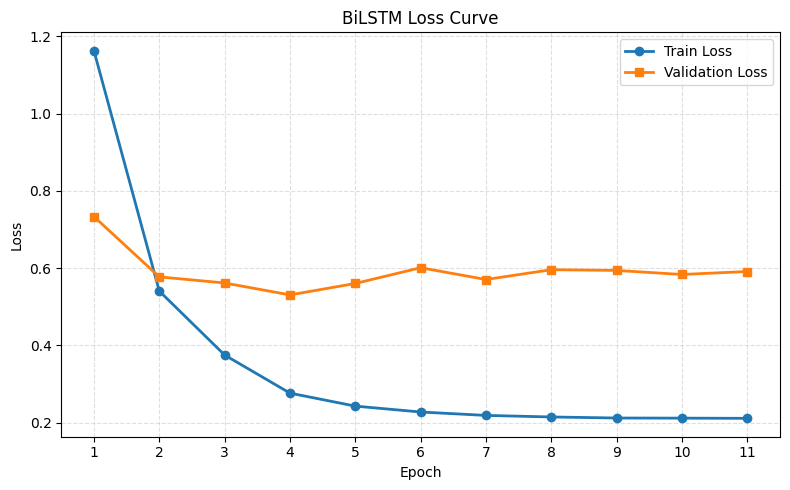

Test loss: 0.4751
Test acc: 0.8675
              precision    recall  f1-score   support

     finance     0.8252    0.8500    0.8374       100
      realty     0.9205    0.8100    0.8617       100
   education     0.9490    0.9300    0.9394       100
     science     0.7928    0.8800    0.8341       100

    accuracy                         0.8675       400
   macro avg     0.8719    0.8675    0.8682       400
weighted avg     0.8719    0.8675    0.8682       400

[[85  2  1 12]
 [ 9 81  1  9]
 [ 3  2 93  2]
 [ 6  3  3 88]]


In [7]:
# 模块7：训练循环、loss 曲线绘制与最终测试
best_dev_acc = -1.0
best_dev_loss = float('inf')
# history 用于记录每个 epoch 的训练/验证指标，便于后续画图分析
history = []
patience_counter = 0

for epoch in range(1, config.num_epochs + 1):
    # 每轮先在训练集更新参数，再在验证集上评估泛化能力
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer=optimizer)
    dev_loss, dev_acc, _, _ = run_epoch(model, dev_loader, optimizer=None)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(dev_loss)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'dev_loss': dev_loss,
        'dev_acc': dev_acc,
        'learning_rate': current_lr,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f}, train acc={train_acc:.4f} | "
        f"dev loss={dev_loss:.4f}, dev acc={dev_acc:.4f} | "
        f"lr={current_lr:.6f}"
    )

    # BiLSTM 优先按验证集准确率保存；若准确率相同，则比较验证集 loss
    if dev_acc > best_dev_acc or (dev_acc == best_dev_acc and dev_loss < best_dev_loss):
        best_dev_acc = dev_acc
        best_dev_loss = dev_loss
        torch.save(model.state_dict(), config.save_path)
        patience_counter = 0
        print(f'Best model saved to: {config.save_path}')
    else:
        patience_counter += 1

    if patience_counter >= config.early_stop_patience:
        print(f'Early stopping triggered at epoch {epoch:02d}.')
        break

# 根据 history 绘制训练集和验证集的 loss 变化曲线
epochs = [record['epoch'] for record in history]
train_losses = [record['train_loss'] for record in history]
dev_losses = [record['dev_loss'] for record in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, dev_losses, marker='s', linewidth=2, label='Validation Loss')
plt.title('BiLSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(config.loss_curve_path, dpi=300, bbox_inches='tight')
print(f'Loss curve saved to: {config.loss_curve_path}')
plt.show()

# 载入验证集表现最好的模型，再在测试集上做最终评估
model.load_state_dict(torch.load(config.save_path, map_location=config.device))
test_loss, test_acc, test_labels, test_preds = run_epoch(model, test_loader, optimizer=None)

print(f'Test loss: {test_loss:.4f}')
print(f'Test acc: {test_acc:.4f}')
print(classification_report(
    test_labels,
    test_preds,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
))
print(confusion_matrix(test_labels, test_preds))


In [8]:
# 模块8：单条文本预测函数
def predict_text(text):
    model.eval()
    tokens = tokenize(text)[: config.max_length]
    if not tokens:
        tokens = [UNK_TOKEN]

    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]
    input_ids = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(config.device)
    lengths = torch.tensor([len(ids)], dtype=torch.long).to(config.device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    label_id = int(np.argmax(probs))
    return {
        'text': text,
        'label_id': label_id,
        'label_name': class_names[label_id],
        'probabilities': {class_names[i]: float(probs[i]) for i in range(len(class_names))},
    }


example = test_samples[0][2]
predict_text(example)


{'text': '供应真紧张棉价很凶猛',
 'label_id': 0,
 'label_name': 'finance',
 'probabilities': {'finance': 0.9292346239089966,
  'realty': 0.02369745820760727,
  'education': 0.023220110684633255,
  'science': 0.023847855627536774}}